# Localisation of E-Cad Positive Nuclei

In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import math
import os
import pathlib
from joblib import Parallel, delayed

from skimage import exposure, measure, util
from skimage.filters import threshold_otsu, gaussian,  threshold_minimum, threshold_local, threshold_yen
from skimage.segmentation import clear_border, find_boundaries, watershed, expand_labels
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, closing, opening, ball, skeletonize, thin, dilation, erosion
from skimage.transform import rescale
from skimage.feature import peak_local_max

from scipy.ndimage import distance_transform_edt
from scipy import ndimage as ndi

from tifffile import imread
import tifffile
from typing import Tuple, List

import contextlib
import joblib
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from textwrap import wrap
from matplotlib.patches import Patch
from matplotlib.collections import PatchCollection
from scipy.stats import linregress

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from matplotlib.colors import ListedColormap
from scipy.spatial import Voronoi
import napari
import re
import warnings
warnings.filterwarnings("ignore")
mycol = ["red", "darkorange", "yellow", "limegreen", "dodgerblue", "darkviolet", "deeppink" ]

In [42]:
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib to report into tqdm progress bar given as argument"""
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

In [3]:
def pixel_size(tif_path):
    with tifffile.TiffFile(tif_path) as tif:
        tif_tags = {}
        for tag in tif.pages[0].tags.values():
            name, value = tag.name, tag.value
            tif_tags[name] = value

        x_pixel_size_um = 1/((tif_tags["XResolution"])[0]/(tif_tags["XResolution"][1]))
        y_pixel_size_um = 1/((tif_tags["YResolution"])[0]/(tif_tags["YResolution"][1]))
        try:
            z_pixel_size_um = float(str(tif_tags["IJMetadata"]).split("nscales=")[1].split(",")[2].split("\\nunit")[0])
        except:
            z_pixel_size_um = (float(str(tif_tags["ImageDescription"]).split("spacing=")[1].split("loop")[0]))
       
    original_spacing = [x_pixel_size_um,y_pixel_size_um,z_pixel_size_um]
    return original_spacing

In [4]:
def convert(img, target_type_min, target_type_max, target_type):
    imin = img.min()
    imax = img.max()

    a = (target_type_max - target_type_min) / (imax - imin)
    b = target_type_max - a * imax
    new_img = (a * img + b).astype(target_type)
    return new_img

In [5]:
def add_image_details(df, flag, filename):
    df["filename"] = filename
    df["flag"] = flag
    if ("well1" in filename):
        df["well"] = 1
    else:
        df["well"] = 2
    # Day #        
    if "d0" in filename:
        df["day"] =  0
    elif "d1" in filename:
        df["day"] =  1
    elif "d3" in filename:
        df["day"] =  3
    else:
        df["day"] =  7
    # Stiffness
    if 'soft' in filename:
        df["condition"] =  'soft'
    elif 'stiff' in filename:
        df["condition"] =  'stiff'
    else:
        df["condition"] =  'blank'
    df['image_type'] = df["condition"].astype(str) + ", d" + df["day"].astype(str)
    return df

In [6]:
def segment_and_quantify(i, image_paths, segmentation_paths, DAPI_channel = 0, membrane_channel = 2, poi_channel = 1, to_plot=False): 
    flag= "None"
    filename = os.path.basename(image_paths[i]).replace("_", "").lower()
    try:
        multi_channel_image = convert(imread(image_paths[i]), 0,255, np.uint8)
        dapi_mask = imread(segmentation_paths[i])
        acinus_image = (multi_channel_image[:,DAPI_channel,:,:] + multi_channel_image[:,membrane_channel,:,:]) # approximate the acinus as membrane + dapi

        original_spacing = pixel_size(image_paths[i]) #alter the z spacing so x,y,z all have the same pixel size
        scale_change = original_spacing[2] / original_spacing[0]
        new_pixel_size = 4 * original_spacing[0]

        acinus_rescaled = rescale(scale = (0.25*scale_change, 0.25, 0.25), image = acinus_image, anti_aliasing= False)
        poi_rescaled = rescale(scale = (0.25*scale_change, 0.25, 0.25), image = multi_channel_image[:, poi_channel,:,:], anti_aliasing= False)
        rescaled_dapi_mask = rescale(scale = (0.25*scale_change, 0.25, 0.25), image = dapi_mask, anti_aliasing= False)
        acinus_rescaled = gaussian(acinus_rescaled, sigma = 5)
        clipped = acinus_rescaled.clip(min =np.quantile(acinus_rescaled, 0.1), max = np.quantile(acinus_rescaled, 0.85))
        thresh = threshold_otsu(clipped)
        binary = clipped > thresh

        binary = remove_small_holes(binary, area_threshold = 100000)
        binary = remove_small_objects(binary, min_size = 10000)

        labelled_image = label(binary)
        table = regionprops_table(labelled_image, properties=('label', "area"),) #only keep largest acinus
        condition = (table['area'] >= (table["area"]).max())
        input_labels = table['label']
        output_labels = input_labels * condition
        filtered_labelled_image = util.map_array(labelled_image, input_labels, output_labels)

        table = regionprops_table(filtered_labelled_image, properties=('label', 'inertia_tensor_eigvals'),) #test sphericity of largest identified acinus
        condition = table['inertia_tensor_eigvals-2']/table['inertia_tensor_eigvals-0'] >= (0.5)
    ################################################################################################################
        if condition == False:
            #low sphericity could mean that 2 neighbouring acini have been imaged. Attempt to separate these with heavy erosion if so
            flag = "multiple_acini_split"
            acinus_smoothed = gaussian(clipped, sigma = 1)
            thresh = threshold_otsu(acinus_smoothed)
            binary = acinus_smoothed > thresh
            binary = remove_small_holes(binary, area_threshold = 100000)
            binary = remove_small_objects(binary, min_size = 10000)
            binary = erosion(binary, ball(8))
            labelled_image = label(binary)
            table = regionprops_table(labelled_image, properties=('label', "area"),)
            condition = (table['area'] >= (table["area"]).max())
            input_labels = table['label']
            output_labels = input_labels * condition
            filtered_labelled_image = util.map_array(labelled_image, input_labels, output_labels)
            filtered_labelled_image = expand_labels(filtered_labelled_image, distance=8)

        acinus_vol_in_um = [(region.area)*(new_pixel_size**3) for region in regionprops(filtered_labelled_image)]
        
        
        cleaned_dapi_mask = rescaled_dapi_mask * filtered_labelled_image
        cleaned_dapi_mask = gaussian(cleaned_dapi_mask, 0.8)
        thresh = threshold_otsu(cleaned_dapi_mask)
        cleaned_dapi_mask = cleaned_dapi_mask > thresh
        cleaned_dapi_mask = remove_small_objects(cleaned_dapi_mask, min_size = 90)
        cleaned_dapi_mask = remove_small_holes(cleaned_dapi_mask, area_threshold = 150)
        cleaned_dapi_mask = opening(cleaned_dapi_mask, ball(5))
        #####################WATERSHED NUCLEI####################
        distances = ndi.distance_transform_edt(erosion(cleaned_dapi_mask, ball(3)))
        nuclear_size_in_pixels = 4/new_pixel_size
        coordinates = peak_local_max(distances, min_distance = int(nuclear_size_in_pixels)) ####seed points at least 4um apart
        marker_locations = coordinates.data
        markers = np.zeros(cleaned_dapi_mask.shape, dtype=np.uint32)
        marker_indices = tuple(np.round(marker_locations).astype(int).T)
        markers[marker_indices] = np.arange(len(marker_locations)) + 1
        markers_big = dilation(markers, ball(2))
        segmented = watershed(-distances, markers_big, mask=cleaned_dapi_mask)
        segmented = clear_border(segmented)
        ## Filter out small nuclei
        table = regionprops_table(segmented, properties=('label', 'area'),)
        volume_threshold = (4/3)*np.pi * (2/new_pixel_size)**3     # radius 2um nucleus
        condition = (table['area'] >= volume_threshold)
        input_labels = table['label']
        output_labels = input_labels * condition
        watershed_dapi = util.map_array(segmented, input_labels, output_labels)


        dapi_info = pd.DataFrame(regionprops_table(watershed_dapi, properties=("label", "area")))
        


        distance = (distance_transform_edt(filtered_labelled_image>0)) 
        distance_scaled = np.interp(distance, (distance.min(), distance.max()), (0, +1))
        if pd.DataFrame(regionprops_table(watershed_dapi, properties = ("label", "area", "centroid"))).shape[0] == 0:
            props =pd.DataFrame(columns= ["label", "centroid-0",	"centroid-1",	"centroid-2",	"corresponding_distance_matrix"], data = [[np.NaN,np.NaN,np.NaN,np.NaN,np.NaN, np.NaN]] )
        else:
            props = pd.DataFrame(regionprops_table(watershed_dapi, properties = ("label", "area", "centroid")))
            props["corresponding_distance_matrix"] = props.apply(lambda x: distance_scaled[round(x['centroid-0']), round(x['centroid-1']), round(x['centroid-2'])], axis=1)
            props["nuclear_volume_um"] = props["area"] * new_pixel_size**3
            props.drop('area', axis=1, inplace=True)
            props["nuclear_Ecad"] = props.apply(lambda row: poi_rescaled[watershed_dapi == row["label"]].sum(), axis = 1)
        
        props["acinus_vol_in_um"] = acinus_vol_in_um[0]
        props["number_of_nuclei"] = dapi_info.shape[0]
        props = add_image_details(props, flag, filename)
            
    # Identify number of cells

        


        if to_plot ==True:
            return props, watershed_dapi, poi_rescaled, dapi_mask, filtered_labelled_image


        else:
            return props
    except:
        props =pd.DataFrame(columns= ["label", "centroid-0",	"centroid-1",	"centroid-2",	"corresponding_distance_matrix"], data = [["Fail","Fail","Fail","Fail","Fail"]] )
        props["filename"] = filename#################
        props["flag"] = "FAILED"
        return props


In [13]:
image_root = "E:\\PROTEIN_COLOCALISATION_IMAGES\\Deconvolved_Images\\ECad_C3_DECONVOLVED\\tifs\\final_tifs"
image_paths = list(pathlib.Path(image_root).glob("**/*.tif"))
segmentation_root = "E:\\PROTEIN_COLOCALISATION_IMAGES\\Deconvolved_Images\\ECad_C3_DECONVOLVED\\tifs\\segmentations\\combined_binary_dapi"
segmentation_paths = list(pathlib.Path(segmentation_root).glob("**/*.tif"))
len(image_paths), len(segmentation_paths)



(140, 140)

In [14]:
i=130
props, watershed_dapi, poi_rescaled, dapi_mask, filtered_labelled_image = segment_and_quantify(i, image_paths, segmentation_paths, to_plot=True)

In [15]:
props["av_nuclear_Ecad_intensity"] = props["nuclear_Ecad"]/props["nucelear_volume_um"]

In [17]:
image_root = "E:\\PROTEIN_COLOCALISATION_IMAGES\\Deconvolved_Images\\ECad_C3_DECONVOLVED\\tifs\\final_tifs"
image_paths = list(pathlib.Path(image_root).glob("**/*.tif"))
segmentation_root = "E:\\PROTEIN_COLOCALISATION_IMAGES\\Deconvolved_Images\\ECad_C3_DECONVOLVED\\tifs\\segmentations\\combined_binary_dapi"
segmentation_paths = list(pathlib.Path(segmentation_root).glob("**/*.tif"))
print(len(image_paths), len(segmentation_paths))

with tqdm_joblib(tqdm(desc="Image Analysis", total=len(image_paths))) as progress_bar:
    props = Parallel(n_jobs=3)(delayed(segment_and_quantify)(i, image_paths, segmentation_paths,) for i in range(len(image_paths)))

140 140


Image Analysis: 100%|██████████| 140/140 [42:17<00:00, 18.12s/it]


# Analysis

In [46]:
def voronoi_neighbors(vor):
    neighbors = {i: set() for i in range(len(vor.points))}
    for ridge in vor.ridge_points:
        neighbors[ridge[0]].add(ridge[1])
        neighbors[ridge[1]].add(ridge[0])
    return neighbors

def return_df_with_neighbour_number(df, filename):
    test = df[df["filename"]== filename]
    xs = test["centroid-0"]
    ys = test["centroid-1"]
    zs = test["centroid-2"]
    points = test[["Unnamed: 0", "difference_from_mean","corresponding_distance_matrix",'centroid-0', 'centroid-1', "centroid-2"]].to_numpy()

    vor = Voronoi(points[:, 3:])
    neighbors = voronoi_neighbors(vor)

    number_of_neighbours = []
    for i, neighbor_set in neighbors.items():
        number_of_neighbours.append(len(neighbor_set))
    test["number_of_neighbours"] = number_of_neighbours
    return test


In [18]:
# total = pd.concat(props).reset_index()
# total.to_csv("nuclear_ecad_location_and_amount.csv")

In [47]:
total=pd.read_csv("nuclear_ecad_location_and_amount.csv")

In [48]:
total["av_brightness_of_nucleus"]=total["nuclear_Ecad"]/total["nucelear_volume_um"] ## average brightness of a pixel in a nucleus for E-cadherin
total["total_acinar_intensity"] = total.groupby('filename')['nuclear_Ecad'].transform('sum')
total["total_acinar_volume"] = total.groupby('filename')['nucelear_volume_um'].transform('sum')
total["av_brightness_of_acinus"]=total["total_acinar_intensity"]/total["total_acinar_volume"] ## average brightness of a pixel in a nucleus for E-cadherin across the whole acinus

In [49]:
total["difference_from_mean"] = (total["av_brightness_of_nucleus"]- total["av_brightness_of_acinus"])

total["spread_in_difference_from_mean"] = total["difference_from_mean"].std()
total["mean_difference_from_mean"] = total["difference_from_mean"].mean()

total["upper_lim_3sd_ecad"] = total["mean_difference_from_mean"] + (3*total["spread_in_difference_from_mean"])
total["lower_lim_3sd_ecad"] = total["mean_difference_from_mean"] - (3*total["spread_in_difference_from_mean"])

all_outliers = total[(total["difference_from_mean"]> total["upper_lim_3sd_ecad"])  | (total["difference_from_mean"]< total["lower_lim_3sd_ecad"])]
d7_outliers = all_outliers[all_outliers["day"]==7]
d7 = total[total["day"]==7]

In [50]:
all_dfs = []
for filename in total.filename.unique():
    df_with_neighbours = return_df_with_neighbour_number(total, filename)
    all_dfs.append(df_with_neighbours)
test_neighbours = pd.concat(all_dfs)


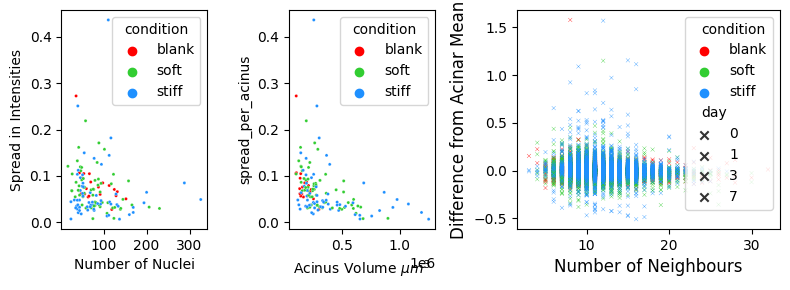

In [75]:
test = total[["filename", 'av_brightness_of_nucleus', "acinus_vol_in_um", "number_of_nuclei", "condition"]]
test["spread_per_acinus"] = total.groupby('filename')['av_brightness_of_nucleus'].transform('std')
test = test.drop_duplicates(subset = "filename", keep="first")
fig, ax = plt.subplots(ncols = 3, figsize=(8,3), gridspec_kw={"width_ratios":[1,1,1.8]})
ax[1].sharey(ax[0])
sns.scatterplot(data = test, x= "number_of_nuclei", y="spread_per_acinus", ax=ax[0], hue="condition", palette =["red", "limegreen", "dodgerblue"], s=5)
sns.scatterplot(data = test, x= "acinus_vol_in_um", y="spread_per_acinus", ax=ax[1], hue="condition", palette =["red", "limegreen", "dodgerblue"], s=5)
ax[0].set_xlabel("Number of Nuclei")
ax[1].set_xlabel(r"Acinus Volume $\mu m^3$")
ax[0].set_ylabel("Spread in Intensities")

#sns.kdeplot(data = test_neighbours, x="number_of_neighbours", y="difference_from_mean", hue="condition", s=8, palette=["red", "limegreen", "dodgerblue"], fill=True, alpha=0.2, ax=ax[2])

sns.scatterplot(data = test_neighbours, x="number_of_neighbours", y="difference_from_mean", hue="condition", s=8, palette=["red", "limegreen", "dodgerblue"], style="day", markers="x", ax=ax[2])
ax[2].set_ylabel("Difference from Acinar Mean", fontsize=12)
ax[2].set_xlabel("Number of Neighbours", fontsize=12)


plt.tight_layout()
plt.savefig("spread_vs_acinuar_params.pdf", transparent=True)

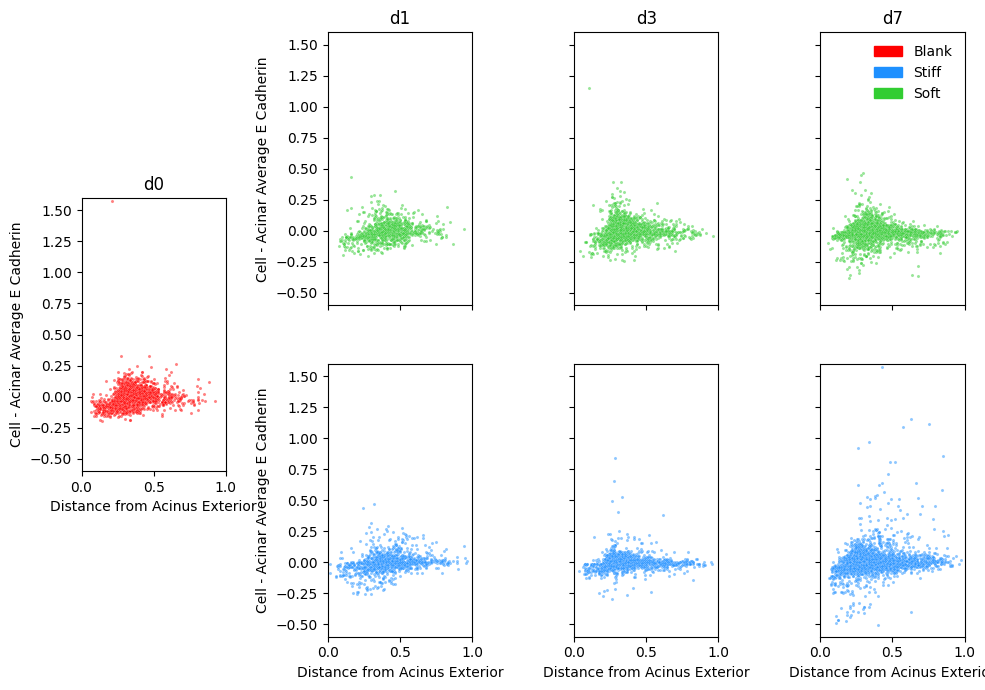

In [9]:
fig = plt.figure( figsize=(10,7))

gs0 = fig.add_gridspec(ncols = 4, nrows=4)

d0_ax = fig.add_subplot(gs0[1:3, 0])
d1_so_ax = fig.add_subplot(gs0[:2, 1])
d3_so_ax = fig.add_subplot(gs0[:2, 2], sharey=d1_so_ax)
d7_so_ax = fig.add_subplot(gs0[:2, 3], sharey=d1_so_ax)

d1_st_ax = fig.add_subplot(gs0[2:, 1])
d3_st_ax = fig.add_subplot(gs0[2:, 2], sharey=d1_st_ax)
d7_st_ax = fig.add_subplot(gs0[2:, 3], sharey=d1_st_ax)

axs = [d0_ax, d1_so_ax, d1_st_ax, d3_so_ax, d3_st_ax,d7_so_ax, d7_st_ax]
plt.setp(d3_so_ax.get_yticklabels(), visible=False)
plt.setp(d7_so_ax.get_yticklabels(), visible=False)
plt.setp(d3_st_ax.get_yticklabels(), visible=False)
plt.setp(d7_st_ax.get_yticklabels(), visible=False)
plt.setp(d1_so_ax.get_xticklabels(), visible=False)
plt.setp(d3_so_ax.get_xticklabels(), visible=False)
plt.setp(d7_so_ax.get_xticklabels(), visible=False)


for day in [0,1,3,7]:
    if day==0:
        ax = d0_ax
        sns.scatterplot(data = total[total["day"]==day], y="difference_from_mean", x= "corresponding_distance_matrix", alpha=0.5, ax=ax, color="red", s=5)
    else:
        for condition in ["soft", "stiff"]:
            if condition == "soft":
                color = "limegreen"
            else:
                color = "dodgerblue"
            if day==1:
                if condition == "soft":
                    ax=d1_so_ax
                else:
                    ax=d1_st_ax
            elif day==3:
                if condition == "soft":
                    ax=d3_so_ax
                else:
                    ax=d3_st_ax
            elif day==7:
                if condition == "soft":
                    ax=d7_so_ax
                else:
                    ax=d7_st_ax
            sns.scatterplot(data = total[(total["day"]==day) & (total["condition"]==condition)], y="difference_from_mean", x= "corresponding_distance_matrix", alpha=0.5, ax=ax, color=color,s=5)

for ax in axs:
    ax.set_ylim(-0.6,1.6)
    ax.set_xlim(0,1)
    ax.set_xlabel("Distance from Acinus Exterior")
    ax.set_ylabel("Cell - Acinar Average E Cadherin")

blank_patch = mpatches.Patch(color='red', label='Blank')
soft_patch = mpatches.Patch(color='dodgerblue', label='Stiff')
stiff_patch = mpatches.Patch(color='limegreen', label='Soft')

d7_so_ax.legend(handles=[blank_patch, soft_patch, stiff_patch], frameon=False)
d0_ax.set_title("d0")
d1_so_ax.set_title("d1")
d3_so_ax.set_title("d3")
d7_so_ax.set_title("d7")


plt.tight_layout()  # Adjust layout to make room for subplot labels/titles
plt.savefig("ecad_alldays_CFMEAN.pdf")

In [34]:
palette = ["deeppink", "darkorange"]
sns_colors = sns.color_palette(palette)
cmap = ListedColormap(sns_colors)


y=total["difference_from_mean"]
x= total["corresponding_distance_matrix"]
data = np.column_stack((x, y))

gmm = GaussianMixture(n_components=2, covariance_type='full')
gmm.fit(data)
clusters = gmm.predict(data)

group1 = data[clusters == 0]
group2 = data[clusters == 1]
slope1, intercept1, r_value1, p_value1, std_err1 = linregress(group1[:, 0], group1[:, 1])
slope2, intercept2, r_value2, p_value2, std_err2 = linregress(group2[:, 0], group2[:, 1])


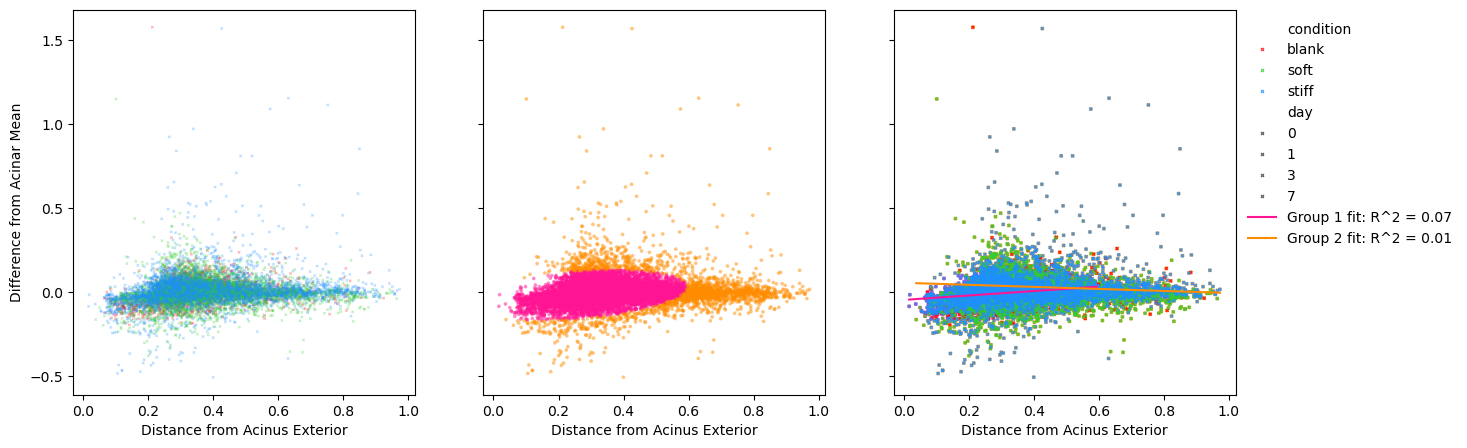

In [35]:

# Plot the original data with cluster colors
fig, ax = plt.subplots(ncols=3, figsize=(15,5), sharey=True)
sns.scatterplot(data = total, y="difference_from_mean", x= "corresponding_distance_matrix", alpha=0.3, ax=ax[0], hue="condition",s=5, palette=["red","limegreen", "dodgerblue"], zorder=100, style="day", markers="X",linewidth=0, legend=False)


ax[1].scatter(data[:, 0], data[:, 1], c=clusters, cmap=cmap, alpha=0.5, s=7, linewidths=0, edgecolor="face")


sns.scatterplot(data = total, y="difference_from_mean", x= "corresponding_distance_matrix", alpha=0.8, ax=ax[2], hue="condition",s=8, palette=["red", "limegreen", "dodgerblue"], zorder=100, style="day", markers="X",linewidth=0)
ax[2].scatter(data[:, 0], data[:, 1], c=clusters, cmap=cmap, alpha=0.8, s=8, linewidths=0, edgecolor="face")

# Plot the lines of best fit
line1_x = np.linspace(group1[:, 0].min(), group1[:, 0].max(), 100)
line1_y = intercept1 + slope1 * line1_x
ax[2].plot(line1_x, line1_y, 'deeppink', label=f'Group 1 fit: R^2 = {r_value1**2:.2f}',zorder=200)

line2_x = np.linspace(group2[:, 0].min(), group2[:, 0].max(), 100)
line2_y = intercept2 + slope2 * line2_x
ax[2].plot(line2_x, line2_y, 'darkorange', label=f'Group 2 fit: R^2 = {r_value2**2:.2f}', zorder=200)
ax[2].legend(frameon=False, bbox_to_anchor=(1, 1))


for a in ax:
    a.set_xlabel("Distance from Acinus Exterior")
ax[0].set_ylabel("Difference from Acinar Mean")
plt.savefig("E_cad_TOTAL_GMM_cfMEAN.pdf", transparent=True, bbox_inches="tight")

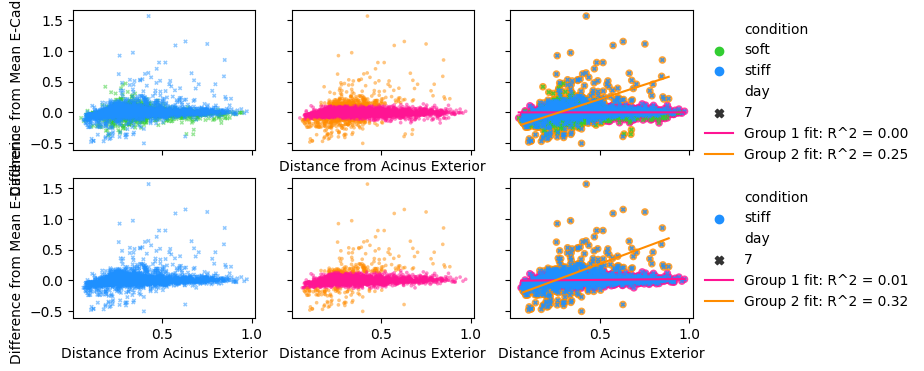

In [89]:
palette = ["deeppink", "darkorange"]
sns_colors = sns.color_palette(palette)
cmap = ListedColormap(sns_colors)

y=d7["difference_from_mean"]
x= d7["corresponding_distance_matrix"]
data = np.column_stack((x, y))

gmm = GaussianMixture(n_components=2, covariance_type='full')
gmm.fit(data)
clusters = gmm.predict(data)

group1 = data[clusters == 0]
group2 = data[clusters == 1]
slope1, intercept1, r_value1, p_value1, std_err1 = linregress(group1[:, 0], group1[:, 1])
slope2, intercept2, r_value2, p_value2, std_err2 = linregress(group2[:, 0], group2[:, 1])

# Plot the original data with cluster colors
fig, ax = plt.subplots(ncols=3, nrows=2,  figsize=(8,4), sharey=True, sharex=True)
sns.scatterplot(data = total[(total["day"]==7)], y="difference_from_mean", x= "corresponding_distance_matrix", alpha=0.5, ax=ax[0,0], hue="condition",s=10, palette=["limegreen", "dodgerblue"], zorder=100, style="day", markers="X",linewidth=0, legend=False)


ax[0,1].scatter(data[:, 0], data[:, 1], c=clusters, cmap=cmap, alpha=0.5, s=7, linewidths=0, edgecolor="face")


sns.scatterplot(data = total[(total["day"]==7)], y="difference_from_mean", x= "corresponding_distance_matrix", alpha=0.8, ax=ax[0,2], hue="condition",s=12, palette=["limegreen", "dodgerblue"], zorder=100, style="day", markers="X",linewidth=0)
ax[0,2].scatter(data[:, 0], data[:, 1], c=clusters, cmap=cmap, alpha=0.8, s=30, linewidths=0, edgecolor="face")

# Plot the lines of best fit
line1_x = np.linspace(group1[:, 0].min(), group1[:, 0].max(), 100)
line1_y = intercept1 + slope1 * line1_x
ax[0,2].plot(line1_x, line1_y, 'deeppink', label=f'Group 1 fit: R^2 = {r_value1**2:.2f}',zorder=200)

line2_x = np.linspace(group2[:, 0].min(), group2[:, 0].max(), 100)
line2_y = intercept2 + slope2 * line2_x
ax[0,2].plot(line2_x, line2_y, 'darkorange', label=f'Group 2 fit: R^2 = {r_value2**2:.2f}', zorder=200)
ax[0,2].legend(frameon=False, bbox_to_anchor=(1, 1))




y=d7[d7["condition"]=="stiff"]["difference_from_mean"]
x= d7[d7["condition"]=="stiff"]["corresponding_distance_matrix"]
data = np.column_stack((x, y))

gmm = GaussianMixture(n_components=2, covariance_type='full')
gmm.fit(data)
clusters = gmm.predict(data)

group1 = data[clusters == 0]
group2 = data[clusters == 1]
slope1, intercept1, r_value1, p_value1, std_err1 = linregress(group1[:, 0], group1[:, 1])
slope2, intercept2, r_value2, p_value2, std_err2 = linregress(group2[:, 0], group2[:, 1])

# Plot the original data with cluster colors

sns.scatterplot(data = total[(total["day"]==7)& (total["condition"]=="stiff")], y="difference_from_mean", x= "corresponding_distance_matrix", alpha=0.5, ax=ax[1,0], hue="condition",s=10, palette=["dodgerblue"], zorder=100, style="day", markers="X",linewidth=0, legend=False)


ax[1,1].scatter(data[:, 0], data[:, 1], c=clusters, cmap=cmap, alpha=0.5, s=7, linewidths=0, edgecolor="face")


sns.scatterplot(data = total[(total["day"]==7)& (total["condition"]=="stiff")], y="difference_from_mean", x= "corresponding_distance_matrix", alpha=0.8, ax=ax[1,2], hue="condition",s=12, palette=["dodgerblue"], zorder=100, style="day", markers="X",linewidth=0)
ax[1,2].scatter(data[:, 0], data[:, 1], c=clusters, cmap=cmap, alpha=0.8, s=30, linewidths=0, edgecolor="face")

# Plot the lines of best fit
line1_x = np.linspace(group1[:, 0].min(), group1[:, 0].max(), 100)
line1_y = intercept1 + slope1 * line1_x
ax[1,2].plot(line1_x, line1_y, 'deeppink', label=f'Group 1 fit: R^2 = {r_value1**2:.2f}',zorder=200)

line2_x = np.linspace(group2[:, 0].min(), group2[:, 0].max(), 100)
line2_y = intercept2 + slope2 * line2_x
ax[1,2].plot(line2_x, line2_y, 'darkorange', label=f'Group 2 fit: R^2 = {r_value2**2:.2f}', zorder=200)
ax[1,2].legend(frameon=False, bbox_to_anchor=(1, 1))






for a in ax.flatten():
    a.set_xlabel("Distance from Acinus Exterior")
ax[0,0].set_ylabel("Difference from Mean E-Cadherin")
ax[1,0].set_ylabel("Difference from Mean E-Cadherin")
plt.savefig("E_cad_d7_GMM_cfMEAN.pdf", transparent=True, bbox_inches="tight")



d7 0.985055482304034 -0.14694722884227765 0.3633488975156441 7.0580141928187995e-06 0.21121418427619076
d7 1.3303244023939271 -0.34179297690899546 0.5029298522026192 3.3786719257928113e-08 0.22311752802609294


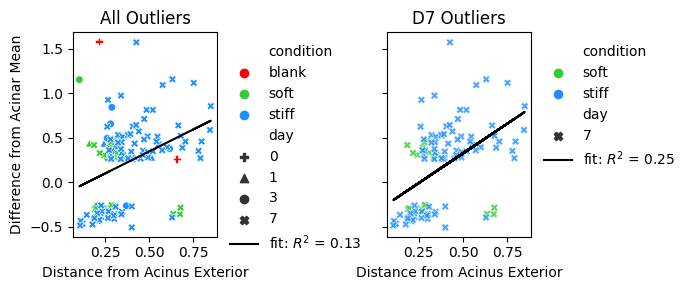

In [77]:
fig, ax = plt.subplots(ncols = 2, sharey=True, figsize=(7,3))

x = all_outliers["corresponding_distance_matrix"]
y = all_outliers["difference_from_mean"]
slope, intercept, r_value, p_value, std_err = linregress(x, y)
sns.scatterplot(data = all_outliers, y="difference_from_mean", x= "corresponding_distance_matrix", hue="condition", style="day", markers=["P", "^", "o", "X"], s=30, palette=["red", "limegreen", "dodgerblue"], ax=ax[0])
ax[0].plot(x, intercept + slope*x, 'r', label='fit: $R^2$ = {:.2f}'.format(r_value**2), color="k", linestyle ="-")
ax[0].legend(frameon=False, bbox_to_anchor=(1, 1))
ax[0].set_xlabel("Distance from Acinus Exterior")
ax[0].set_ylabel("Difference from Acinar Mean")
ax[0].set_title("All Outliers")
print("d7", slope, intercept, r_value, p_value, std_err)

x = d7_outliers["corresponding_distance_matrix"]
y = d7_outliers["difference_from_mean"]
slope, intercept, r_value, p_value, std_err = linregress(x, y)
sns.scatterplot(data = d7_outliers, y="difference_from_mean", x= "corresponding_distance_matrix", hue="condition", s=30, alpha=0.8, palette=["limegreen", "dodgerblue"], ax=ax[1], markers = "X", style="day")
ax[1].plot(x, intercept + slope*x, 'r', label='fit: $R^2$ = {:.2f}'.format(r_value**2),color="k", linestyle ="-")
print("d7", slope, intercept, r_value, p_value, std_err)
ax[1].legend(frameon=False, bbox_to_anchor=(1, 1))
ax[1].set_xlabel("Distance from Acinus Exterior")
ax[1].set_ylabel("Difference from Acinar Mean")
ax[1].set_title("D7 Outliers")


plt.tight_layout()
plt.savefig("ecad_outliers_CFMEAN.pdf", transparent= True)

# Looks at absolute values only -> NOT USEFUL

In [ ]:
total["ecad_av_intensity"] = total["nuclear_Ecad"]/total["nucelear_volume_um"]

In [136]:
total["mean_ecad"] = total["ecad_av_intensity"].mean()
total["std_ecad"] = total["ecad_av_intensity"].std()
total["upper_lim_3sd_ecad"] = total["mean_ecad"] + (3*total["std_ecad"])
all_outliers = total[total["ecad_av_intensity"]> total["upper_lim_3sd_ecad"]]
d7_outliers = all_outliers[all_outliers["day"]==7]

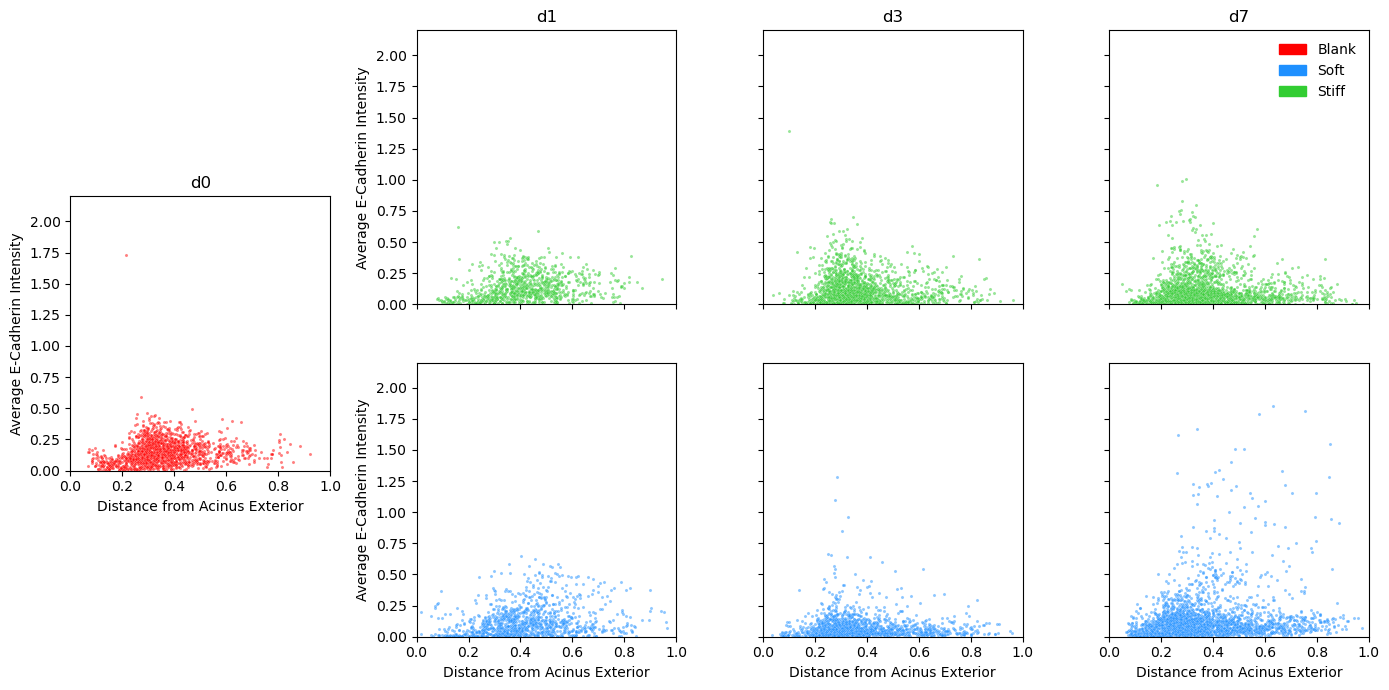

In [134]:
fig = plt.figure( figsize=(14,7))

gs0 = fig.add_gridspec(ncols = 4, nrows=4)

d0_ax = fig.add_subplot(gs0[1:3, 0])
d1_so_ax = fig.add_subplot(gs0[:2, 1])
d1_st_ax = fig.add_subplot(gs0[2:, 1])
d3_so_ax = fig.add_subplot(gs0[:2, 2], sharey=d1_so_ax)
d3_st_ax = fig.add_subplot(gs0[2:, 2], sharey=d1_st_ax)
d7_so_ax = fig.add_subplot(gs0[:2, 3], sharey=d1_so_ax)
d7_st_ax = fig.add_subplot(gs0[2:, 3], sharey=d1_st_ax)
axs = [d0_ax, d1_so_ax, d1_st_ax, d3_so_ax, d3_st_ax,d7_so_ax, d7_st_ax]
plt.setp(d3_so_ax.get_yticklabels(), visible=False)
plt.setp(d7_so_ax.get_yticklabels(), visible=False)
plt.setp(d3_st_ax.get_yticklabels(), visible=False)
plt.setp(d7_st_ax.get_yticklabels(), visible=False)
plt.setp(d1_so_ax.get_xticklabels(), visible=False)
plt.setp(d3_so_ax.get_xticklabels(), visible=False)
plt.setp(d7_so_ax.get_xticklabels(), visible=False)


for day in [0,1,3,7]:
    if day==0:
        ax = d0_ax
        sns.scatterplot(data = total[total["day"]==day], y="ecad_av_intensity", x= "corresponding_distance_matrix", alpha=0.5, ax=ax, color="red", s=5)
    else:
        for condition in ["soft", "stiff"]:
            if condition == "soft":
                color = "limegreen"
            else:
                color = "dodgerblue"
            if day==1:
                if condition == "soft":
                    ax=d1_so_ax
                else:
                    ax=d1_st_ax
            elif day==3:
                if condition == "soft":
                    ax=d3_so_ax
                else:
                    ax=d3_st_ax
            elif day==7:
                if condition == "soft":
                    ax=d7_so_ax
                else:
                    ax=d7_st_ax
            sns.scatterplot(data = total[(total["day"]==day) & (total["condition"]==condition)], y="ecad_av_intensity", x= "corresponding_distance_matrix", alpha=0.5, ax=ax, color=color,s=5)

for ax in axs:
    ax.set_ylim(0,2.2)
    ax.set_xlim(0,1)
    ax.set_xlabel("Distance from Acinus Exterior")
    ax.set_ylabel("Average E-Cadherin Intensity")

blank_patch = mpatches.Patch(color='red', label='Blank')
soft_patch = mpatches.Patch(color='dodgerblue', label='Soft')
stiff_patch = mpatches.Patch(color='limegreen', label='Stiff')

d7_so_ax.legend(handles=[blank_patch, soft_patch, stiff_patch], frameon=False)
d0_ax.set_title("d0")
d1_so_ax.set_title("d1")
d3_so_ax.set_title("d3")
d7_so_ax.set_title("d7")


plt.tight_layout()  # Adjust layout to make room for subplot labels/titles
plt.savefig("d7_ecad_nuclear_localisation.pdf")

0.5021745335679807 0.6483890013777632 0.25540307309037497 0.003007020950378332 0.16609062981744188


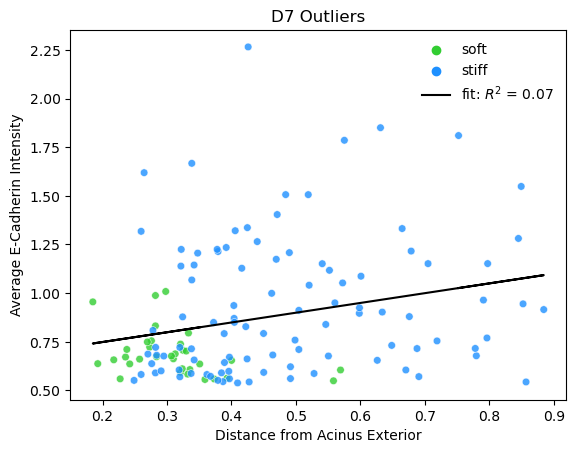

In [137]:
x = d7_outliers["corresponding_distance_matrix"]
y = d7_outliers["ecad_av_intensity"]

fig, ax = plt.subplots()
slope, intercept, r_value, p_value, std_err = linregress(x, y)
sns.scatterplot(data = d7_outliers, y="ecad_av_intensity", x= "corresponding_distance_matrix", hue="condition", s=30, alpha=0.8, palette=["limegreen", "dodgerblue"], ax=ax)
ax.plot(x, intercept + slope*x, 'r', label='fit: $R^2$ = {:.2f}'.format(r_value**2),color="k", linestyle ="-")
print(slope, intercept, r_value, p_value, std_err)
ax.legend(frameon=False, bbox_to_anchor=(1, 1))
ax.set_xlabel("Distance from Acinus Exterior")
ax.set_ylabel("Average E-Cadherin Intensity")
ax.set_title("D7 Outliers")
plt.savefig("d7_ecad_outliers.pdf")

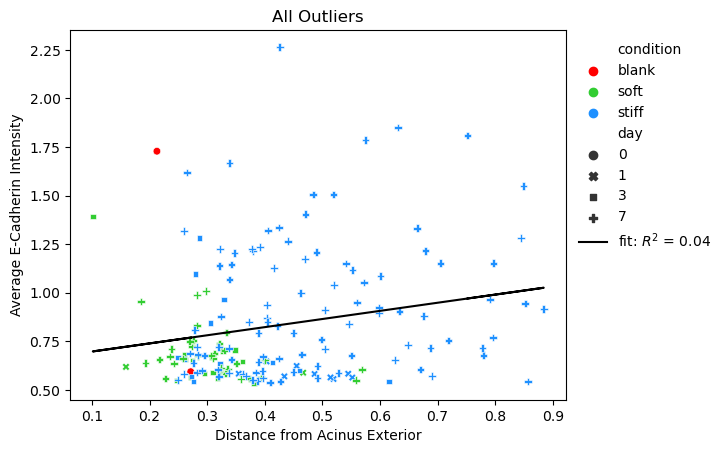

In [138]:
x = all_outliers["corresponding_distance_matrix"]
y = all_outliers["ecad_av_intensity"]
slope, intercept, r_value, p_value, std_err = linregress(x, y)

fig, ax = plt.subplots()
sns.scatterplot(data = all_outliers, y="ecad_av_intensity", x= "corresponding_distance_matrix", hue="condition", style="day", s=30, palette=["red", "limegreen", "dodgerblue"], ax=ax)
ax.plot(x, intercept + slope*x, 'r', label='fit: $R^2$ = {:.2f}'.format(r_value**2), color="k", linestyle ="-")
ax.legend(frameon=False, bbox_to_anchor=(1, 1))
ax.set_xlabel("Distance from Acinus Exterior")
ax.set_ylabel("Average E-Cadherin Intensity")
ax.set_title("All Outliers")
plt.savefig("all_ecad_outliers.pdf")

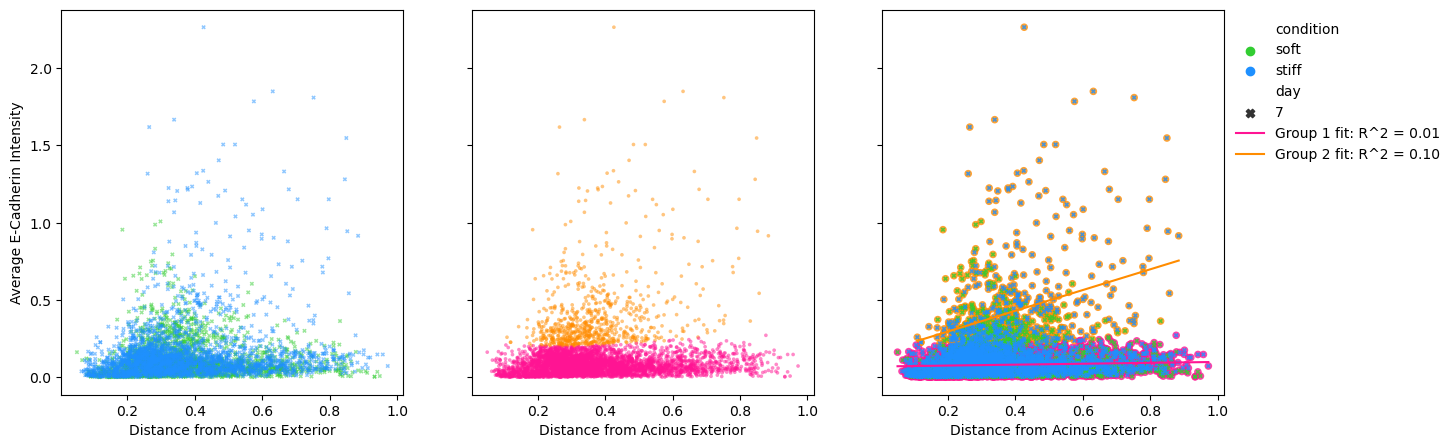

In [225]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from matplotlib.colors import ListedColormap


palette = ["deeppink", "darkorange"]
sns_colors = sns.color_palette(palette)
cmap = ListedColormap(sns_colors)


y=d7["ecad_av_intensity"]
x= d7["corresponding_distance_matrix"]
data = np.column_stack((x, y))

gmm = GaussianMixture(n_components=2, covariance_type='full')
gmm.fit(data)
clusters = gmm.predict(data)

group1 = data[clusters == 0]
group2 = data[clusters == 1]
slope1, intercept1, r_value1, p_value1, std_err1 = linregress(group1[:, 0], group1[:, 1])
slope2, intercept2, r_value2, p_value2, std_err2 = linregress(group2[:, 0], group2[:, 1])

# Plot the original data with cluster colors
fig, ax = plt.subplots(ncols=3, figsize=(15,5), sharey=True)
sns.scatterplot(data = total[(total["day"]==7)], y="ecad_av_intensity", x= "corresponding_distance_matrix", alpha=0.5, ax=ax[0], hue="condition",s=10, palette=["limegreen", "dodgerblue"], zorder=100, style="day", markers="X",linewidth=0, legend=False)


ax[1].scatter(data[:, 0], data[:, 1], c=clusters, cmap=cmap, alpha=0.5, s=7, linewidths=0, edgecolor="face")


sns.scatterplot(data = total[(total["day"]==7)], y="ecad_av_intensity", x= "corresponding_distance_matrix", alpha=0.8, ax=ax[2], hue="condition",s=12, palette=["limegreen", "dodgerblue"], zorder=100, style="day", markers="X",linewidth=0)
ax[2].scatter(data[:, 0], data[:, 1], c=clusters, cmap=cmap, alpha=0.8, s=30, linewidths=0, edgecolor="face")

# Plot the lines of best fit
line1_x = np.linspace(group1[:, 0].min(), group1[:, 0].max(), 100)
line1_y = intercept1 + slope1 * line1_x
ax[2].plot(line1_x, line1_y, 'deeppink', label=f'Group 1 fit: R^2 = {r_value1**2:.2f}',zorder=200)

line2_x = np.linspace(group2[:, 0].min(), group2[:, 0].max(), 100)
line2_y = intercept2 + slope2 * line2_x
ax[2].plot(line2_x, line2_y, 'darkorange', label=f'Group 2 fit: R^2 = {r_value2**2:.2f}', zorder=200)
ax[2].legend(frameon=False, bbox_to_anchor=(1, 1))


for a in ax:
    a.set_xlabel("Distance from Acinus Exterior")
ax[0].set_ylabel("Average E-Cadherin Intensity")
plt.savefig("E_cad_d7_GMM.pdf", transparent=True, bbox_inches="tight")